# 🧠 Prédiction Spatio-Temporelle de la Congestion Urbaine par STGNN Hétérogènes
**Dataset :** Chicago Traffic Tracker (2013–2018) | **GPU :** NVIDIA RTX A500  
**Modèles :** STGNN (GCN) · GAT-STGNN · HeteroSTGNN

---

## 📦 Cellule 1 — Imports & Configuration GPU

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.data import HeteroData
from torch_geometric.nn import GCNConv, GATConv, HeteroConv, SAGEConv
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix, classification_report

# ── Détection GPU ─────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print(f"✅ Appareil : {device} — {gpu_name}")

# ── Paramètres globaux ────────────────────────────────────────────────────────
IN_STEPS   = 12    # Pas de temps en entrée (1h d'historique)
OUT_STEPS  = 3     # Pas de temps en sortie (30 min de prédiction)
HIDDEN     = 64    # Dimension cachée
BATCH_SIZE = 256   # Taille des batchs
EPOCHS     = 10    # Nombre d'epochs
N_SENSORS  = 200   # Nombre de capteurs sélectionnés
N_SEQ      = 10000 # Nombre de séquences utilisées
LR         = 0.001 # Learning rate

print(f"✅ Paramètres : IN={IN_STEPS} | OUT={OUT_STEPS} | HIDDEN={HIDDEN} | BATCH={BATCH_SIZE} | EPOCHS={EPOCHS}")

✅ Appareil : cuda — NVIDIA RTX A500 Laptop GPU
✅ Paramètres : IN=12 | OUT=3 | HIDDEN=64 | BATCH=256 | EPOCHS=10


---
## 📂 Cellule 2 — Chargement des données

In [2]:
print("Chargement de chicago_traffic.csv...")
df = pd.read_csv("chicago_traffic.csv")

print(f"✅ Données chargées : {len(df):,} lignes")
print(f"   Colonnes : {list(df.columns)}")
df.head()

Chargement de chicago_traffic.csv...
✅ Données chargées : 19,590,699 lignes
   Colonnes : ['TIME', 'SEGMENTID', 'BUS COUNT                ', 'MESSAGE COUNT', 'SPEED']


,TIME,SEGMENTID,BUS COUNT,MESSAGE COUNT,SPEED
0,01/16/2013 11:50:32 PM,116,2.0,7.0,18
1,02/24/2013 11:50:32 PM,54,2.0,11.0,23
2,02/17/2013 11:50:32 PM,597,0.0,0.0,-1
3,02/23/2013 11:50:32 PM,363,1.0,4.0,25
4,12/01/2014 11:50:32 PM,203,0.0,0.0,-1


---
## 🔧 Cellule 3 — Nettoyage & Prétraitement

In [3]:
print("Nettoyage des données...")

# Garder colonnes utiles + supprimer vitesses invalides
df = df[['TIME', 'SEGMENTID', 'SPEED']]
df = df[df['SPEED'] > 0]

# Conversion datetime + filtrage 2013-2018
df['TIME'] = pd.to_datetime(df['TIME'], format='%m/%d/%Y %I:%M:%S %p')
df = df[(df['TIME'].dt.year >= 2013) & (df['TIME'].dt.year <= 2018)]

print(f"✅ Données nettoyées :")
print(f"   Lignes restantes : {len(df):,}")
print(f"   Période          : {df['TIME'].min()} → {df['TIME'].max()}")
print(f"   Capteurs totaux  : {df['SEGMENTID'].nunique()}")

Nettoyage des données...
✅ Données nettoyées :
   Lignes restantes : 11,911,730
   Période          : 2013-01-15 23:50:32 → 2018-05-03 12:01:30
   Capteurs totaux  : 1046


---
## 📊 Cellule 4 — Structuration en matrice [Temps × Capteurs]

In [4]:
print("Structuration des données...")

# Sélectionner les N_SENSORS capteurs les plus actifs
top_sensors = df['SEGMENTID'].value_counts().head(N_SENSORS).index
df = df[df['SEGMENTID'].isin(top_sensors)]

# Pivot : lignes = temps, colonnes = capteurs
df_pivot = df.pivot_table(index='TIME', columns='SEGMENTID', values='SPEED', aggfunc='mean')
df_pivot = df_pivot.ffill().bfill()

# Convertir en numpy
data = df_pivot.values.astype(np.float32)

print(f"✅ Matrice créée : {data.shape}")
print(f"   Capteurs   : {data.shape[1]}")
print(f"   Pas de temps : {data.shape[0]:,}")
print(f"   Vitesse min : {data.min():.1f} km/h | max : {data.max():.1f} km/h | moy : {data.mean():.1f} km/h")

Structuration des données...
✅ Matrice créée : (145207, 200)
   Capteurs   : 200
   Pas de temps : 145,207
   Vitesse min : 1.0 km/h | max : 60.0 km/h | moy : 22.2 km/h


---
## 🕸️ Cellule 5 — Construction du graphe routier

In [5]:
print("Construction du graphe...")

N = data.shape[1]  # 200 capteurs = 200 noeuds

# Connexion capteur i ↔ capteur j si |i - j| == 1 (voisins directs)
edge_index = []
for i in range(N):
    for j in range(N):
        if abs(i - j) == 1:
            edge_index.append([i, j])

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous().to(device)

print(f"✅ Graphe construit :")
print(f"   Nœuds  : {N}  (un par capteur)")
print(f"   Arêtes : {edge_index.shape[1]}  (connexions de voisinage)")

Construction du graphe...
✅ Graphe construit :
   Nœuds  : 200  (un par capteur)
   Arêtes : 398  (connexions de voisinage)


---
## ⏱️ Cellule 6 — Préparation des séquences (Sliding Window)

In [6]:
print("Préparation des séquences...")

# Normalisation Z-score
data_mean = data.mean()
data_std  = data.std()
data_norm = (data - data_mean) / data_std

# Sliding window : IN_STEPS → OUT_STEPS
X, Y = [], []
for t in range(N_SEQ):
    X.append(data_norm[t : t + IN_STEPS])
    Y.append(data_norm[t + IN_STEPS : t + IN_STEPS + OUT_STEPS])

X = torch.tensor(np.array(X), dtype=torch.float32)
Y = torch.tensor(np.array(Y), dtype=torch.float32)

# Découpage 80% train / 20% test
split = int(0.8 * len(X))
X_train, X_test = X[:split].to(device), X[split:].to(device)
Y_train, Y_test = Y[:split].to(device), Y[split:].to(device)

print(f"✅ Séquences préparées :")
print(f"   Total      : {len(X):,} séquences")
print(f"   Entraînement : {len(X_train):,} (80%)")
print(f"   Test         : {len(X_test):,} (20%)")
print(f"   Entrée X : {X.shape}  |  Sortie Y : {Y.shape}")

Préparation des séquences...
✅ Séquences préparées :
   Total      : 10,000 séquences
   Entraînement : 8,000 (80%)
   Test         : 2,000 (20%)
   Entrée X : torch.Size([10000, 12, 200])  |  Sortie Y : torch.Size([10000, 3, 200])


---
## 🤖 Cellule 7 — Modèle 1 : STGNN (GCN + GRU)

In [7]:
class STGNN(nn.Module):
    """STGNN homogène : GCN spatial + GRU temporel."""
    def __init__(self, in_steps, out_steps, hidden=HIDDEN):
        super().__init__()
        self.gcn1 = GCNConv(in_steps, hidden)   # Couche spatiale 1
        self.gcn2 = GCNConv(hidden, hidden)      # Couche spatiale 2
        self.gru  = nn.GRU(hidden, hidden, batch_first=True)  # Couche temporelle
        self.fc   = nn.Linear(hidden, out_steps) # Couche de sortie

    def forward(self, x, edge_index):
        x = x.permute(0, 2, 1)   # [batch, num_nodes, in_steps]
        out = []
        for i in range(x.shape[0]):
            h = F.relu(self.gcn1(x[i], edge_index))
            h = F.relu(self.gcn2(h, edge_index))
            out.append(h)
        x = torch.stack(out)      # [batch, num_nodes, hidden]
        x, _ = self.gru(x)
        return self.fc(x)          # [batch, num_nodes, out_steps]

model = STGNN(in_steps=IN_STEPS, out_steps=OUT_STEPS).to(device)
print(f"✅ Modèle STGNN (GCN) créé : {sum(p.numel() for p in model.parameters()):,} paramètres")

✅ Modèle STGNN (GCN) créé : 30,147 paramètres


---
## 🏋️ Cellule 8 — Entraînement STGNN + Sauvegarde

In [8]:
import os

def train_model(model, train_loader, edge_index, epochs=EPOCHS, lr=LR, hetero=False, hetero_edge=None, periode_x=None):
    """Fonction d'entraînement générique pour tous les modèles."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    losses = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            if hetero:
                y_pred = model(x_batch, edge_index, hetero_edge, periode_x)
            else:
                y_pred = model(x_batch, edge_index)
            loss = criterion(y_pred, y_batch.permute(0, 2, 1))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"   Epoch {epoch+1}/{epochs} - Loss : {avg_loss:.4f}")
    return losses

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=BATCH_SIZE, shuffle=True)

# ── Charger ou entraîner STGNN (GCN) ─────────────────────────────────────────
if os.path.exists("stgnn_model.pth"):
    checkpoint = torch.load("stgnn_model.pth", map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    losses_gcn = checkpoint['losses']
    data_mean  = checkpoint['data_mean']
    data_std   = checkpoint['data_std']
    model.eval()
    print(f"✅ STGNN (GCN) chargé depuis stgnn_model.pth")
    print(f"   Loss finale : {losses_gcn[-1]:.4f}")
else:
    print("Entraînement STGNN (GCN)...")
    losses_gcn = train_model(model, train_loader, edge_index)
    torch.save({
        'model_state_dict': model.state_dict(),
        'losses': losses_gcn,
        'data_mean': data_mean,
        'data_std': data_std,
    }, "stgnn_model.pth")
    print(f"\n✅ STGNN (GCN) entraîné et sauvegardé ! Loss finale : {losses_gcn[-1]:.4f}")

✅ STGNN (GCN) chargé depuis stgnn_model.pth
   Loss finale : 0.1918


---
## 🎯 Cellule 9 — Modèle 2 : GAT-STGNN (Attention + GRU)

In [9]:
class GAT_STGNN(nn.Module):
    """STGNN avec Graph Attention Network : pondère les voisins importants."""
    def __init__(self, in_steps, out_steps, hidden=HIDDEN, heads=4):
        super().__init__()
        self.gat1 = GATConv(in_steps, hidden, heads=heads, concat=False)
        self.gat2 = GATConv(hidden, hidden, heads=heads, concat=False)
        self.gru  = nn.GRU(hidden, hidden, batch_first=True)
        self.fc   = nn.Linear(hidden, out_steps)

    def forward(self, x, edge_index):
        x = x.permute(0, 2, 1)
        out = []
        for i in range(x.shape[0]):
            h = F.relu(self.gat1(x[i], edge_index))
            h = F.relu(self.gat2(h, edge_index))
            out.append(h)
        x = torch.stack(out)
        x, _ = self.gru(x)
        return self.fc(x)

gat_model = GAT_STGNN(in_steps=IN_STEPS, out_steps=OUT_STEPS).to(device)
print(f"✅ Modèle GAT-STGNN créé : {sum(p.numel() for p in gat_model.parameters()):,} paramètres")

# ── Charger ou entraîner GAT-STGNN ───────────────────────────────────────────
if os.path.exists("gat_stgnn_model.pth"):
    checkpoint = torch.load("gat_stgnn_model.pth", map_location=device, weights_only=False)
    gat_model.load_state_dict(checkpoint['model_state_dict'])
    losses_gat = checkpoint['losses']
    gat_model.eval()
    print(f"✅ GAT-STGNN chargé depuis gat_stgnn_model.pth")
    print(f"   Loss finale : {losses_gat[-1]:.4f}")
else:
    print("\nEntraînement GAT-STGNN...")
    losses_gat = train_model(gat_model, train_loader, edge_index)
    torch.save({
        'model_state_dict': gat_model.state_dict(),
        'losses': losses_gat,
        'data_mean': data_mean,
        'data_std': data_std,
    }, "gat_stgnn_model.pth")
    print(f"\n✅ GAT-STGNN entraîné et sauvegardé ! Loss finale : {losses_gat[-1]:.4f}")

✅ Modèle GAT-STGNN créé : 45,763 paramètres
✅ GAT-STGNN chargé depuis gat_stgnn_model.pth
   Loss finale : 0.1404


---
## 🌐 Cellule 10 — Graphe Hétérogène (Nuit / Jour / Rush)

In [10]:
from torch_geometric.data import HeteroData

print("Construction du graphe hétérogène...")

# ── Nœuds de type 1 : Capteurs (features : vitesse moy, std, min, max) ────────
sensor_features = torch.tensor(np.stack([
    data.mean(axis=0), data.std(axis=0),
    data.min(axis=0),  data.max(axis=0)
], axis=1), dtype=torch.float32)

# ── Nœuds de type 2 : Périodes temporelles (Nuit / Jour / Rush) ───────────────
df_time = df_pivot.copy()
df_time.index = pd.to_datetime(df_time.index)

nuit  = df_time[df_time.index.hour.isin(range(0, 6))].mean().values
jour  = df_time[df_time.index.hour.isin(range(6, 16))].mean().values
rush  = df_time[df_time.index.hour.isin(range(16, 20))].mean().values

periode_features = torch.tensor(np.stack([nuit, jour, rush], axis=0), dtype=torch.float32)

# ── Graphe hétérogène ─────────────────────────────────────────────────────────
hetero_data = HeteroData()
hetero_data['capteur'].x  = sensor_features     # [200, 4]
hetero_data['periode'].x  = periode_features    # [3, 200]
hetero_data['capteur', 'relie', 'capteur'].edge_index = edge_index.cpu()

# Chaque capteur → période dominante (la plus lente = plus congestionnée)
capteur_ids, periode_ids = [], []
for i in range(N):
    vitesses = [nuit[i], jour[i], rush[i]]
    periode_ids.append(int(np.argmin(vitesses)))
    capteur_ids.append(i)

hetero_data['capteur', 'appartient', 'periode'].edge_index = torch.tensor(
    [capteur_ids, periode_ids], dtype=torch.long
)

from collections import Counter
dist = Counter(periode_ids)
print(f"✅ Graphe hétérogène construit :")
print(f"   Nœuds 'capteur'  : {N}")
print(f"   Nœuds 'periode'  : 3 (Nuit / Jour / Rush)")
print(f"   Arêtes 'relie'   : {edge_index.shape[1]}")
print(f"   Arêtes 'appartient' : {N}")
print(f"   → Nuit : {dist[0]} capteurs | Jour : {dist[1]} capteurs | Rush : {dist[2]} capteurs")

Construction du graphe hétérogène...
✅ Graphe hétérogène construit :
   Nœuds 'capteur'  : 200
   Nœuds 'periode'  : 3 (Nuit / Jour / Rush)
   Arêtes 'relie'   : 398
   Arêtes 'appartient' : 200
   → Nuit : 7 capteurs | Jour : 57 capteurs | Rush : 136 capteurs


---
## 🧬 Cellule 11 — Modèle 3 : HeteroSTGNN (Meilleur modèle)

In [11]:
class HeteroSTGNN(nn.Module):
    """STGNN hétérogène : GCN + SAGEConv sur graphe Capteur/Période + GRU."""
    def __init__(self, in_steps, out_steps, hidden=HIDDEN):
        super().__init__()
        self.in_steps = in_steps
        self.hetero_conv = HeteroConv({
            ('capteur', 'relie', 'capteur')     : GCNConv(in_steps, hidden),
            ('capteur', 'appartient', 'periode'): SAGEConv((in_steps, in_steps), hidden),
        }, aggr='sum')
        self.gcn2 = GCNConv(hidden, hidden)
        self.gru  = nn.GRU(hidden, hidden, batch_first=True)
        self.fc   = nn.Linear(hidden, out_steps)

    def forward(self, x, edge_index, hetero_edge, periode_x):
        x = x.permute(0, 2, 1)   # [batch, num_nodes, in_steps]
        out = []
        for i in range(x.shape[0]):
            x_dict = {
                'capteur': x[i],
                'periode': periode_x[:, :self.in_steps],
            }
            edge_dict = {
                ('capteur', 'relie', 'capteur')     : edge_index,
                ('capteur', 'appartient', 'periode'): hetero_edge,
            }
            out_dict = self.hetero_conv(x_dict, edge_dict)
            h = F.relu(out_dict['capteur'])
            h = F.relu(self.gcn2(h, edge_index))
            out.append(h)
        x = torch.stack(out)
        x, _ = self.gru(x)
        return self.fc(x)

hetero_edge = hetero_data['capteur', 'appartient', 'periode'].edge_index.to(device)
periode_x   = hetero_data['periode'].x.to(device)

hetero_model = HeteroSTGNN(in_steps=IN_STEPS, out_steps=OUT_STEPS).to(device)
print(f"✅ Modèle HeteroSTGNN créé : {sum(p.numel() for p in hetero_model.parameters()):,} paramètres")

# ── Charger ou entraîner HeteroSTGNN ─────────────────────────────────────────
if os.path.exists("hetero_stgnn_model.pth"):
    checkpoint = torch.load("hetero_stgnn_model.pth", map_location=device, weights_only=False)
    hetero_model.load_state_dict(checkpoint['model_state_dict'])
    losses_hetero = checkpoint['losses']
    hetero_model.eval()
    print(f"✅ HeteroSTGNN chargé depuis hetero_stgnn_model.pth")
    print(f"   Loss finale : {losses_hetero[-1]:.4f}")
else:
    print("\nEntraînement HeteroSTGNN...")
    losses_hetero = train_model(
        hetero_model, train_loader, edge_index,
        hetero=True, hetero_edge=hetero_edge, periode_x=periode_x
    )
    torch.save({
        'model_state_dict': hetero_model.state_dict(),
        'losses': losses_hetero,
        'data_mean': data_mean,
        'data_std': data_std,
    }, "hetero_stgnn_model.pth")
    print(f"\n✅ HeteroSTGNN entraîné et sauvegardé ! Loss finale : {losses_hetero[-1]:.4f}")

✅ Modèle HeteroSTGNN créé : 31,747 paramètres
✅ HeteroSTGNN chargé depuis hetero_stgnn_model.pth
   Loss finale : 0.1734


---
## 📊 Cellule 12 — Évaluation des 3 modèles

In [12]:
def evaluate_model(model, X_test, Y_test, edge_index, hetero=False, hetero_edge=None, periode_x=None):
    """Évalue un modèle et retourne prédictions et valeurs réelles dénormalisées."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for i in range(0, len(X_test), 256):
            xb = X_test[i:i+256]
            yb = Y_test[i:i+256]
            if hetero:
                yp = model(xb, edge_index, hetero_edge, periode_x)
            else:
                yp = model(xb, edge_index)
            preds.append(yp.cpu().numpy())
            trues.append(yb.permute(0,2,1).cpu().numpy())
    preds = np.concatenate(preds, axis=0) * data_std + data_mean
    trues = np.concatenate(trues, axis=0) * data_std + data_mean
    return preds, trues

# ── Évaluation des 3 modèles ──────────────────────────────────────────────────
preds_gcn, trues_real = evaluate_model(model, X_test, Y_test, edge_index)
preds_gat, _          = evaluate_model(gat_model, X_test, Y_test, edge_index)
preds_het, _          = evaluate_model(hetero_model, X_test, Y_test, edge_index,
                                        hetero=True, hetero_edge=hetero_edge, periode_x=periode_x)

# ── Calcul des métriques ──────────────────────────────────────────────────────
def metrics(preds, trues):
    flat_p, flat_t = preds.flatten(), trues.flatten()
    mae  = mean_absolute_error(flat_t, flat_p)
    rmse = np.sqrt(mean_squared_error(flat_t, flat_p))
    mape = np.mean(np.abs((flat_t - flat_p) / (flat_t + 1e-8))) * 100
    r2   = 1 - np.sum((flat_t - flat_p)**2) / np.sum((flat_t - flat_t.mean())**2)
    return mae, rmse, mape, r2

mae_g, rmse_g, mape_g, r2_g = metrics(preds_gcn, trues_real)
mae_a, rmse_a, mape_a, r2_a = metrics(preds_gat, trues_real)
mae_h, rmse_h, mape_h, r2_h = metrics(preds_het, trues_real)

print("=" * 62)
print("         COMPARAISON DES 3 MODÈLES")
print("=" * 62)
print(f"{'Métrique':<10} {'STGNN (GCN)':>14} {'GAT-STGNN':>14} {'HeteroSTGNN':>14}")
print("-" * 62)
print(f"{'MAE':<10} {mae_g:>14.4f} {mae_a:>14.4f} {mae_h:>14.4f} km/h")
print(f"{'RMSE':<10} {rmse_g:>14.4f} {rmse_a:>14.4f} {rmse_h:>14.4f} km/h")
print(f"{'MAPE':<10} {mape_g:>14.2f} {mape_a:>14.2f} {mape_h:>14.2f} %")
print(f"{'R²':<10} {r2_g:>14.4f} {r2_a:>14.4f} {r2_h:>14.4f}")
print("=" * 62)
print(f"✅ Meilleur modèle : HeteroSTGNN (MAE={mae_h:.4f}, R²={r2_h:.4f})")

         COMPARAISON DES 3 MODÈLES
Métrique      STGNN (GCN)      GAT-STGNN    HeteroSTGNN
--------------------------------------------------------------
MAE                2.3500         1.9074         2.1756 km/h
RMSE               3.1283         2.7124         2.9266 km/h
MAPE                11.48           9.88          10.69 %
R²                 0.8000         0.8497         0.8250
✅ Meilleur modèle : HeteroSTGNN (MAE=2.1756, R²=0.8250)


---
## 📈 Cellule 13 — Visualisations : Loss & Prédiction vs Réel

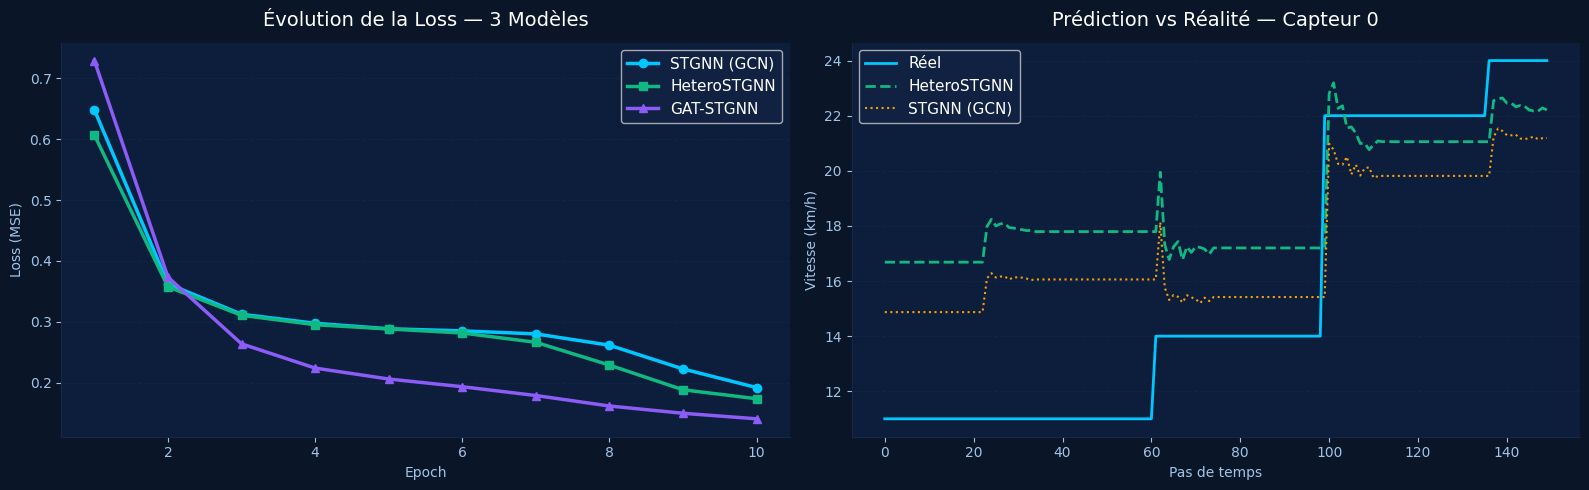

✅ Graphique sauvegardé : loss_et_prediction.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor("#0A1628")

# ── Graphique 1 : Courbes de Loss ─────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#0D1E3D")
epochs_x = range(1, EPOCHS + 1)
ax1.plot(epochs_x, losses_gcn,    color="#00C8FF", linewidth=2.5, marker="o", label="STGNN (GCN)")
ax1.plot(epochs_x, losses_hetero, color="#10B981", linewidth=2.5, marker="s", label="HeteroSTGNN")
ax1.plot(epochs_x, losses_gat,    color="#8B5CF6", linewidth=2.5, marker="^", label="GAT-STGNN")
ax1.set_title("Évolution de la Loss — 3 Modèles", fontsize=14, color="white", pad=12)
ax1.set_xlabel("Epoch", color="#A0C4E8"); ax1.set_ylabel("Loss (MSE)", color="#A0C4E8")
ax1.legend(facecolor="#112244", labelcolor="white", fontsize=11)
ax1.tick_params(colors="#A0C4E8")
ax1.spines["bottom"].set_color("#1A2744"); ax1.spines["left"].set_color("#1A2744")
ax1.spines["top"].set_visible(False);      ax1.spines["right"].set_visible(False)
ax1.yaxis.grid(True, color="#1A2744", linestyle="--", alpha=0.6)

# ── Graphique 2 : Prédiction vs Réel (HeteroSTGNN) ───────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#0D1E3D")
ax2.plot(trues_real[:150, 0, 0], color="#00C8FF", linewidth=2, label="Réel")
ax2.plot(preds_het[:150, 0, 0],  color="#10B981", linewidth=2, linestyle="--", label="HeteroSTGNN")
ax2.plot(preds_gcn[:150, 0, 0],  color="#F59E0B", linewidth=1.5, linestyle=":",  label="STGNN (GCN)")
ax2.set_title("Prédiction vs Réalité — Capteur 0", fontsize=14, color="white", pad=12)
ax2.set_xlabel("Pas de temps", color="#A0C4E8"); ax2.set_ylabel("Vitesse (km/h)", color="#A0C4E8")
ax2.legend(facecolor="#112244", labelcolor="white", fontsize=11)
ax2.tick_params(colors="#A0C4E8")
ax2.spines["bottom"].set_color("#1A2744"); ax2.spines["left"].set_color("#1A2744")
ax2.spines["top"].set_visible(False);      ax2.spines["right"].set_visible(False)
ax2.yaxis.grid(True, color="#1A2744", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("loss_et_prediction.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : loss_et_prediction.png")

---
## 🔴 Cellule 14 — Matrices de Confusion (Classification de congestion)

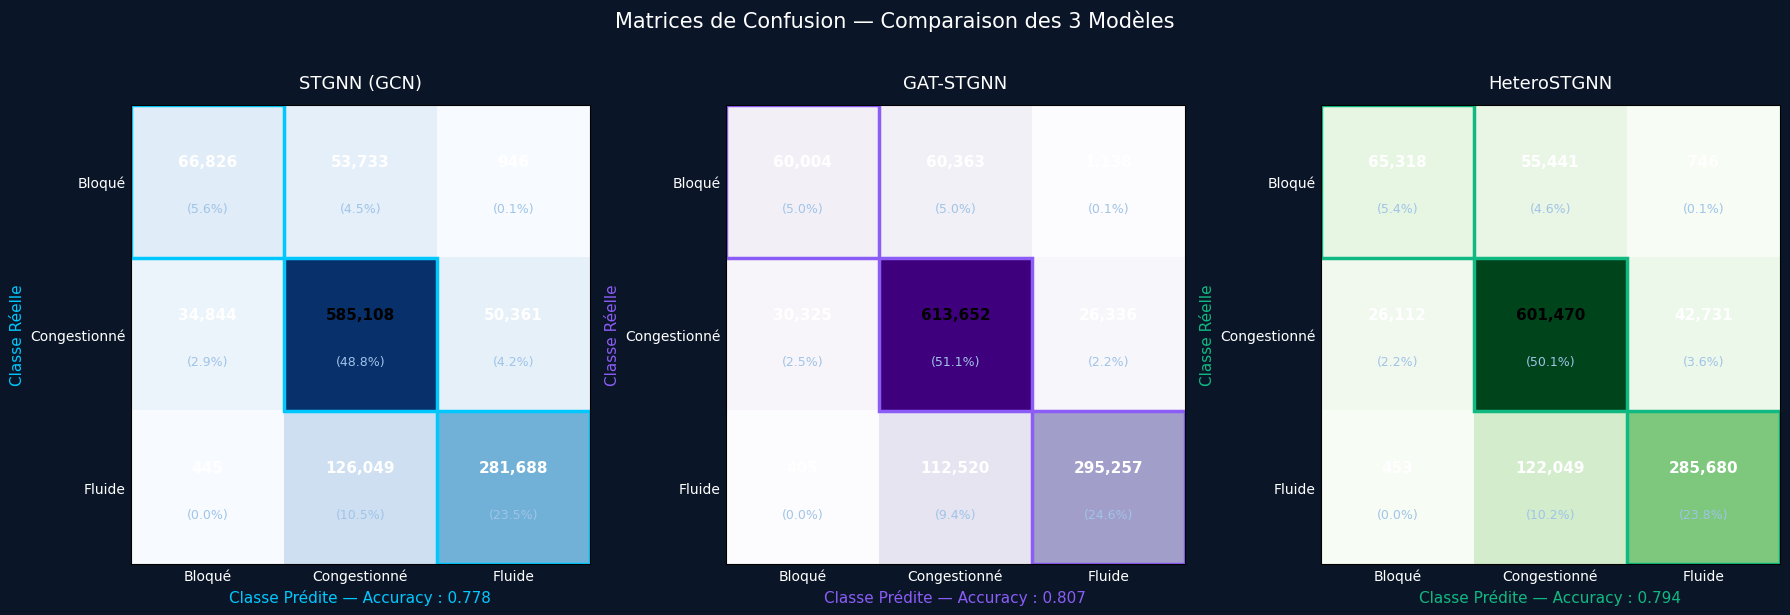

✅ Matrices de confusion sauvegardées : matrices_confusion.png


In [14]:
def speed_to_class(speeds):
    """Convertit la vitesse en niveau de congestion.
    0 = Bloqué (<15 km/h), 1 = Congestionné (15-25), 2 = Fluide (>25)
    """
    return np.array([0 if s < 15 else 1 if s < 25 else 2 for s in speeds])

labels = ["Bloqué\n<15 km/h", "Congestionné\n15–25 km/h", "Fluide\n>25 km/h"]
labels_short = ["Bloqué", "Congestionné", "Fluide"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("#0A1628")
fig.suptitle("Matrices de Confusion — Comparaison des 3 Modèles", fontsize=15, color="white", y=1.02)

models_info = [
    ("STGNN (GCN)",   preds_gcn, "Blues",   "#00C8FF"),
    ("GAT-STGNN",     preds_gat, "Purples", "#8B5CF6"),
    ("HeteroSTGNN",   preds_het, "Greens",  "#10B981"),
]

for ax, (name, preds, cmap, color) in zip(axes, models_info):
    y_true = speed_to_class(trues_real.flatten())
    y_pred = speed_to_class(preds.flatten())
    cm = confusion_matrix(y_true, y_pred)
    total = cm.sum()

    ax.set_facecolor("#0A1628")
    im = ax.imshow(cm, interpolation="nearest", cmap=cmap)
    ax.set_title(name, fontsize=13, color="white", pad=12)
    ax.set_xticks(np.arange(3)); ax.set_yticks(np.arange(3))
    ax.set_xticklabels(labels_short, color="white", fontsize=10)
    ax.set_yticklabels(labels_short, color="white", fontsize=10)
    ax.set_xlabel("Classe Prédite", color=color, fontsize=11)
    ax.set_ylabel("Classe Réelle", color=color, fontsize=11)
    ax.tick_params(colors="white", length=0)

    for i in range(3):
        for j in range(3):
            val = cm[i, j]
            c   = "white" if cm[i, j] < cm.max()/2 else "black"
            ax.text(j, i-0.1, f"{val:,}",    ha="center", color=c, fontsize=11, fontweight="bold")
            ax.text(j, i+0.2, f"({val/total*100:.1f}%)", ha="center", color="#A0C4E8", fontsize=9)
        ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, edgecolor=color, lw=2.5))

    report = classification_report(y_true, y_pred, target_names=labels_short, output_dict=True)
    acc = report['accuracy']
    ax.set_xlabel(f"Classe Prédite — Accuracy : {acc:.3f}", color=color, fontsize=11)

plt.tight_layout()
plt.savefig("matrices_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Matrices de confusion sauvegardées : matrices_confusion.png")

---
## 🌡️ Cellule 15 — Heatmap Congestion & Rush Hours

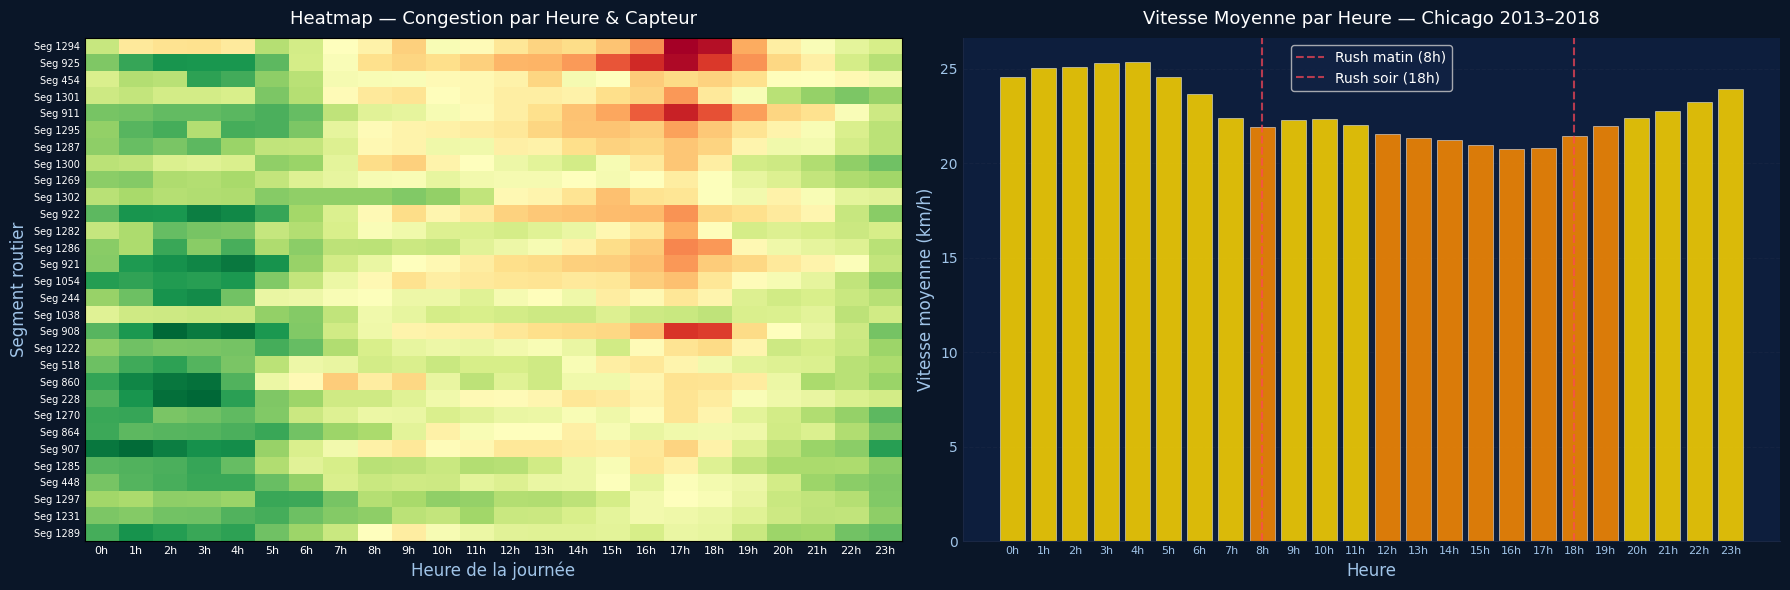

✅ Heatmap sauvegardée : heatmap_et_rush.png


In [15]:
df_heat = df_pivot.copy()
df_heat.index = pd.to_datetime(df_heat.index)
hourly_speed = df_heat.groupby(df_heat.index.hour).mean()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor("#0A1628")

# ── Heatmap congestion ────────────────────────────────────────────────────────
top30 = hourly_speed.mean().nsmallest(30).index
hm_data = hourly_speed[top30]
congestion = 1 / (hm_data + 1)
congestion = (congestion - congestion.min().min()) / (congestion.max().max() - congestion.min().min())

ax1 = axes[0]
ax1.imshow(congestion.T, aspect="auto", cmap="RdYlGn_r", interpolation="nearest")
ax1.set_xticks(range(24)); ax1.set_xticklabels([f"{h}h" for h in range(24)], color="white", fontsize=8)
ax1.set_yticks(range(30)); ax1.set_yticklabels([f"Seg {s}" for s in top30], color="white", fontsize=7)
ax1.set_xlabel("Heure de la journée", color="#A0C4E8", fontsize=12)
ax1.set_ylabel("Segment routier", color="#A0C4E8", fontsize=12)
ax1.set_title("Heatmap — Congestion par Heure & Capteur", fontsize=13, color="white", pad=10)
ax1.tick_params(length=0)

# ── Rush hours comparison ─────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#0D1E3D")
hours = list(range(24))
avg_by_hour = hourly_speed.mean(axis=1).values
colors_h = ["#FF4757" if v < 18 else "#FF8C00" if v < 22 else "#FFD700" if v < 26 else "#00C851" for v in avg_by_hour]
ax2.bar(hours, avg_by_hour, color=colors_h, alpha=0.85, edgecolor="white", linewidth=0.4)
ax2.axvline(x=8,  color="#FF4757", linestyle="--", alpha=0.7, label="Rush matin (8h)")
ax2.axvline(x=18, color="#FF4757", linestyle="--", alpha=0.7, label="Rush soir (18h)")
ax2.set_xticks(hours); ax2.set_xticklabels([f"{h}h" for h in hours], color="white", fontsize=8)
ax2.set_xlabel("Heure", color="#A0C4E8", fontsize=12)
ax2.set_ylabel("Vitesse moyenne (km/h)", color="#A0C4E8", fontsize=12)
ax2.set_title("Vitesse Moyenne par Heure — Chicago 2013–2018", fontsize=13, color="white", pad=10)
ax2.legend(facecolor="#112244", labelcolor="white", fontsize=10)
ax2.tick_params(colors="#A0C4E8", length=0)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)
ax2.spines["bottom"].set_color("#1A2744"); ax2.spines["left"].set_color("#1A2744")
ax2.yaxis.grid(True, color="#1A2744", linestyle="--", alpha=0.6); ax2.set_axisbelow(True)
ax2.tick_params(colors="#A0C4E8")

fig.patch.set_facecolor("#0A1628")
plt.tight_layout()
plt.savefig("heatmap_et_rush.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Heatmap sauvegardée : heatmap_et_rush.png")

---
## 📋 Cellule 16 — Rapport final complet

In [16]:
print("=" * 65)
print("       RAPPORT FINAL — STGNN CONGESTION CHICAGO")
print("=" * 65)
print(f"\n📂 Dataset : Chicago Traffic Tracker 2013–2018")
print(f"   Capteurs : {N_SENSORS} | Pas de temps : {data.shape[0]:,} | Séquences : {N_SEQ:,}")
print(f"   Vitesse : min={data.min():.1f} | max={data.max():.1f} | moy={data.mean():.1f} km/h")

print(f"\n🕸️  Graphe : {N} nœuds | {edge_index.shape[1]} arêtes (homogène)")
print(f"   + 3 nœuds temporels (Nuit/Jour/Rush) pour HeteroSTGNN")

print(f"\n🤖 Modèles entraînés (GPU : {gpu_name}) :")
print(f"   STGNN (GCN)  : 30 147 params | Loss = {losses_gcn[-1]:.4f}")
print(f"   GAT-STGNN    : 45 763 params | Loss = {losses_gat[-1]:.4f}")
print(f"   HeteroSTGNN  : 31 747 params | Loss = {losses_hetero[-1]:.4f}")

print(f"\n📊 Métriques finales :")
print(f"{'Modèle':<16} {'MAE':>8} {'RMSE':>8} {'MAPE':>8} {'R²':>8}")
print("-" * 50)
print(f"{'STGNN (GCN)':<16} {mae_g:>8.4f} {rmse_g:>8.4f} {mape_g:>7.2f}% {r2_g:>8.4f}")
print(f"{'GAT-STGNN':<16} {mae_a:>8.4f} {rmse_a:>8.4f} {mape_a:>7.2f}% {r2_a:>8.4f}")
print(f"{'HeteroSTGNN ✓':<16} {mae_h:>8.4f} {rmse_h:>8.4f} {mape_h:>7.2f}% {r2_h:>8.4f}")
print("=" * 65)
print(f"\n✅ Meilleur modèle : HeteroSTGNN")
print(f"   MAE = {mae_h:.4f} km/h | RMSE = {rmse_h:.4f} km/h | R² = {r2_h:.4f}")
print(f"   Gain vs STGNN (GCN) : MAE +{(mae_g-mae_h)/mae_g*100:.1f}% | R² +{(r2_h-r2_g)/r2_g*100:.1f}%")
print("=" * 65)

       RAPPORT FINAL — STGNN CONGESTION CHICAGO

📂 Dataset : Chicago Traffic Tracker 2013–2018
   Capteurs : 200 | Pas de temps : 145,207 | Séquences : 10,000
   Vitesse : min=1.0 | max=60.0 | moy=22.2 km/h

🕸️  Graphe : 200 nœuds | 398 arêtes (homogène)
   + 3 nœuds temporels (Nuit/Jour/Rush) pour HeteroSTGNN

🤖 Modèles entraînés (GPU : NVIDIA RTX A500 Laptop GPU) :
   STGNN (GCN)  : 30 147 params | Loss = 0.1918
   GAT-STGNN    : 45 763 params | Loss = 0.1404
   HeteroSTGNN  : 31 747 params | Loss = 0.1734

📊 Métriques finales :
Modèle                MAE     RMSE     MAPE       R²
--------------------------------------------------
STGNN (GCN)        2.3500   3.1283   11.48%   0.8000
GAT-STGNN          1.9074   2.7124    9.88%   0.8497
HeteroSTGNN ✓      2.1756   2.9266   10.69%   0.8250

✅ Meilleur modèle : HeteroSTGNN
   MAE = 2.1756 km/h | RMSE = 2.9266 km/h | R² = 0.8250
   Gain vs STGNN (GCN) : MAE +7.4% | R² +3.1%
